# Imports

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Conversion function

In [ ]:
def convert_rgb_image_to_ycbcr(rgb_image):
    """
    Convert an RGB image to YCbCr color space.

    OpenCV uses the channel order:
    Y, Cr, Cb
    for cv2.COLOR_RGB2YCrCb.
    """
    ycrcb_image = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2YCrCb)

    # Rearrange OpenCV's YCrCb output into YCbCr order
    ycbcr_image = ycrcb_image[:, :, [0, 2, 1]]

    return ycbcr_image

# Read and convert Image

In [ ]:
bgr_image = cv2.imread("fabric.png") # opencv reads the image in BGR format

# Convert BGR to RGB because the given image is considered RGB
rgb_image = cv2.cvtColor(bgr_image, cv2.COLOR_BGR2RGB)

# Convert RGB image to YCbCr
ycbcr_image = convert_rgb_image_to_ycbcr(rgb_image)

# Function to Perform 2×2 Block Averaging

In [ ]:
def average_blocks(channel, block_size=2):
    """
    Replace every block_size x block_size block in a channel
    with the average value of that block.
    """

    # Create a copy so the original channel is not modified
    output = channel.copy().astype(np.float64)

    # Get the height and width of the channel
    height, width = channel.shape

    # Process complete blocks
    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):

            # Extract the current block
            block = channel[i:i+block_size, j:j+block_size]

            # Compute the average of the block
            average_value = np.mean(block)

            # Replace all elements with the average
            output[i:i+block_size, j:j+block_size] = average_value

    # Convert back to uint8 for image representation
    return output.astype(np.uint8)

# Extract the Y, Cb, and Cr Channels

In [ ]:
# Extract individual Y, Cb, and Cr channels
Y = ycbcr_image[:, :, 0]
Cb = ycbcr_image[:, :, 1]
Cr = ycbcr_image[:, :, 2]

# Apply 2×2 Block Averaging to Cb and Cr Channels

In [ ]:
Cb_subsampled = average_blocks(Cb, block_size=2)
Cr_subsampled = average_blocks(Cr, block_size=2)

# Construct the New YCbCr Image

In [ ]:
# Create a new YCbCr image
ycbcr_subsampled = np.zeros_like(ycbcr_image)

# Keep the luminance channel unchanged
ycbcr_subsampled[:, :, 0] = Y

# Replace Cb and Cr with the block-averaged channels
ycbcr_subsampled[:, :, 1] = Cr_subsampled
ycbcr_subsampled[:, :, 2] = Cb_subsampled

# Visualize Cb and Cr After 2×2 Chroma Subsampling

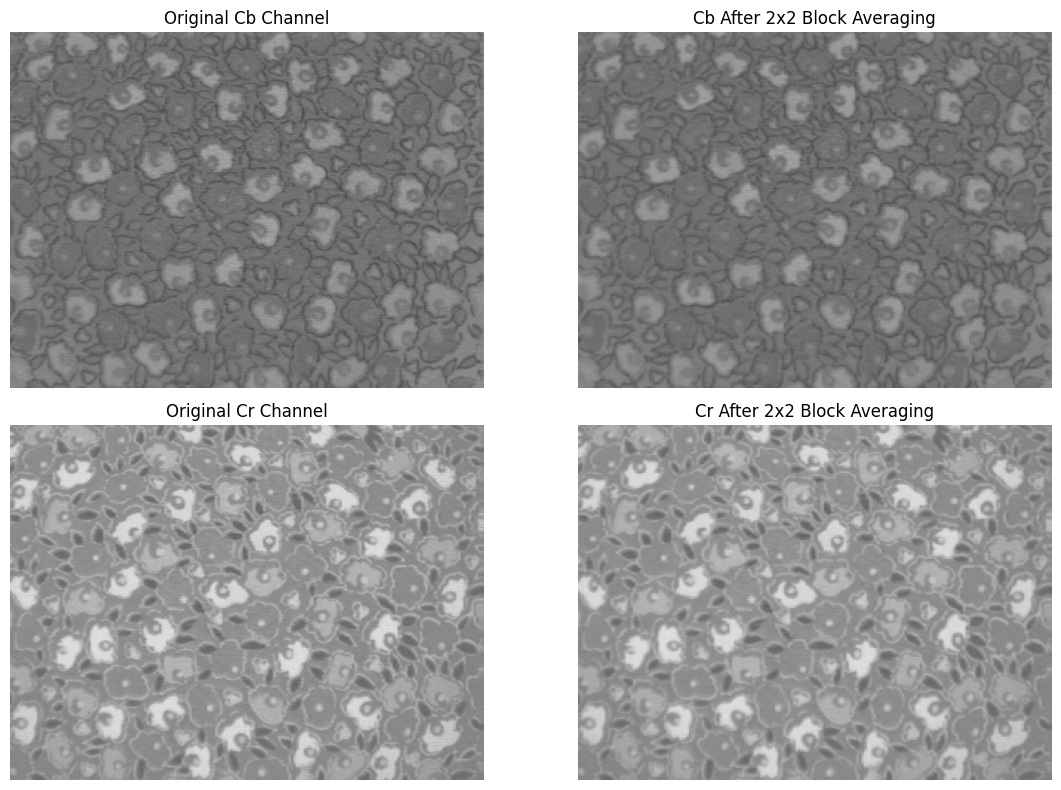

In [ ]:
# Display original and modified chrominance channels
plt.figure(figsize=(12, 8))

# Original Cb channel
plt.subplot(2, 2, 1)
plt.imshow(Cb, cmap="gray", vmin=0, vmax=255)
plt.title("Original Cb Channel")
plt.axis("off")

# Cb after 2x2 block averaging
plt.subplot(2, 2, 2)
plt.imshow(Cb_subsampled, cmap="gray", vmin=0, vmax=255)
plt.title("Cb After 2x2 Block Averaging")
plt.axis("off")

# Original Cr channel
plt.subplot(2, 2, 3)
plt.imshow(Cr, cmap="gray", vmin=0, vmax=255)
plt.title("Original Cr Channel")
plt.axis("off")

# Cr after 2x2 block averaging
plt.subplot(2, 2, 4)
plt.imshow(Cr_subsampled, cmap="gray", vmin=0, vmax=255)
plt.title("Cr After 2x2 Block Averaging")
plt.axis("off")

plt.tight_layout()
plt.show()

# RGB Comparison After Chroma Subsampling

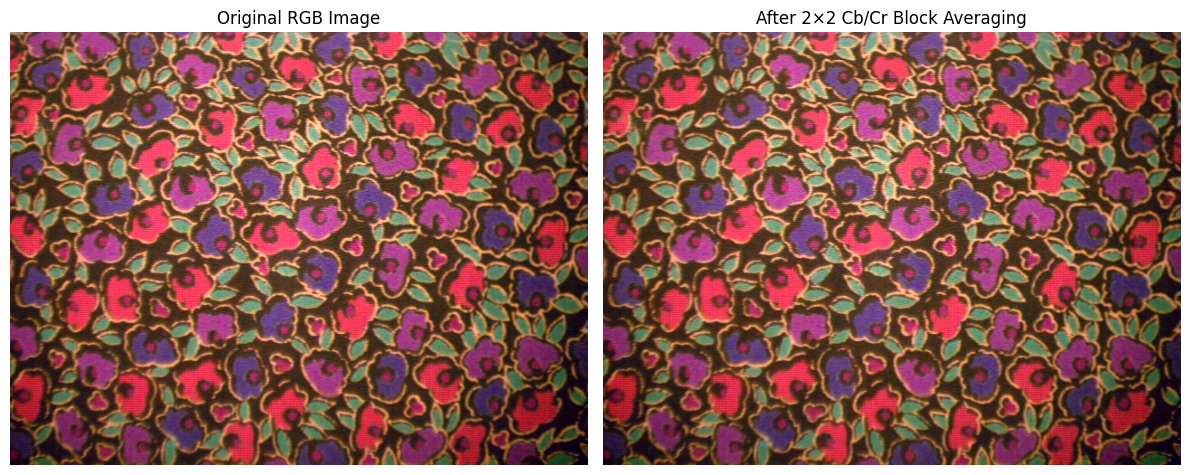

In [ ]:
# Convert modified YCbCr back to RGB

# OpenCV uses YCrCb ordering: [Y, Cr, Cb]
# If your ycbcr_image was created using OpenCV, use this:
rgb_subsampled = cv2.cvtColor(
    ycbcr_subsampled,
    cv2.COLOR_YCrCb2RGB
)

# Plot Original RGB and Block-Averaged RGB

plt.figure(figsize=(12, 5))

# Original RGB image
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# RGB image after Cb and Cr 2x2 block averaging
plt.subplot(1, 2, 2)
plt.imshow(rgb_subsampled)
plt.title("After 2×2 Cb/Cr Block Averaging")
plt.axis("off")

plt.tight_layout()
plt.show()

# Additional experiment: Do the same thing for the RGB channels i.e 2 x 2 block averaging and visualize the result

### 2x2 Block Averaging for RGB Image

In [ ]:
def average_rgb_blocks(image, block_size=2):
    """
    Perform block averaging independently on R, G, and B channels.

    Each block_size x block_size block is replaced by its
    average RGB value.
    """

    # Convert to float for accurate averaging
    output = image.astype(np.float64).copy()

    height, width, channels = image.shape

    # Process each RGB channel independently
    for i in range(0, height - block_size + 1, block_size):
        for j in range(0, width - block_size + 1, block_size):

            # Extract RGB block
            block = image[i:i+block_size, j:j+block_size, :]

            # Average the block separately for R, G, B
            mean_rgb = np.mean(block, axis=(0, 1))

            # Replace the entire block with its average RGB value
            output[i:i+block_size, j:j+block_size, :] = mean_rgb

    return np.clip(output, 0, 255).astype(np.uint8)

In [ ]:
rgb_averaged = average_rgb_blocks(rgb_image, block_size=2)

### Visualize Original RGB and Averaged RGB

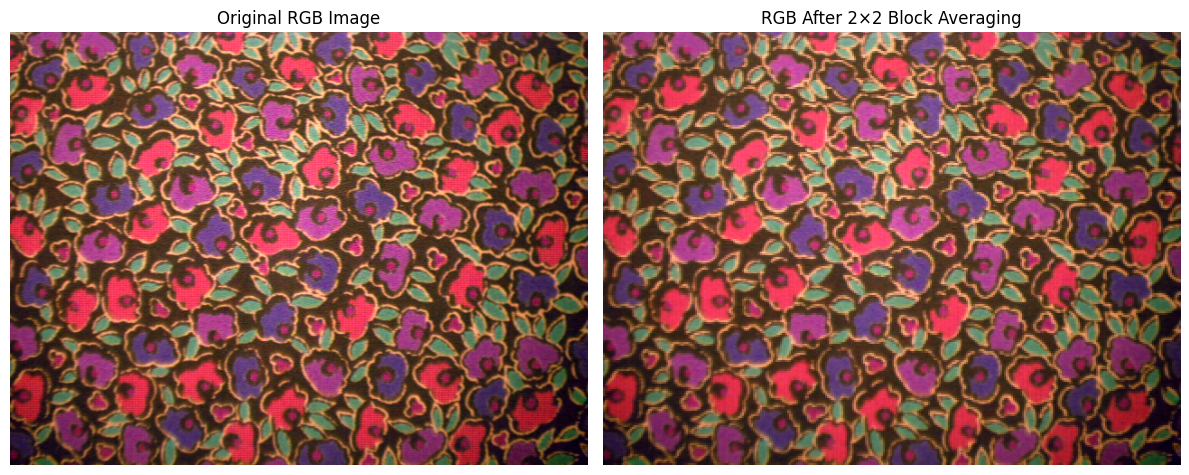

In [ ]:
plt.figure(figsize=(12, 5))

# Original RGB image
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# RGB after 2x2 block averaging
plt.subplot(1, 2, 2)
plt.imshow(rgb_averaged)
plt.title("RGB After 2×2 Block Averaging")
plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# let's do it for 5 by 5 for both YCbCr and RGB and see the result

# Compare both for 5 x 5 averaging

# YCbCr

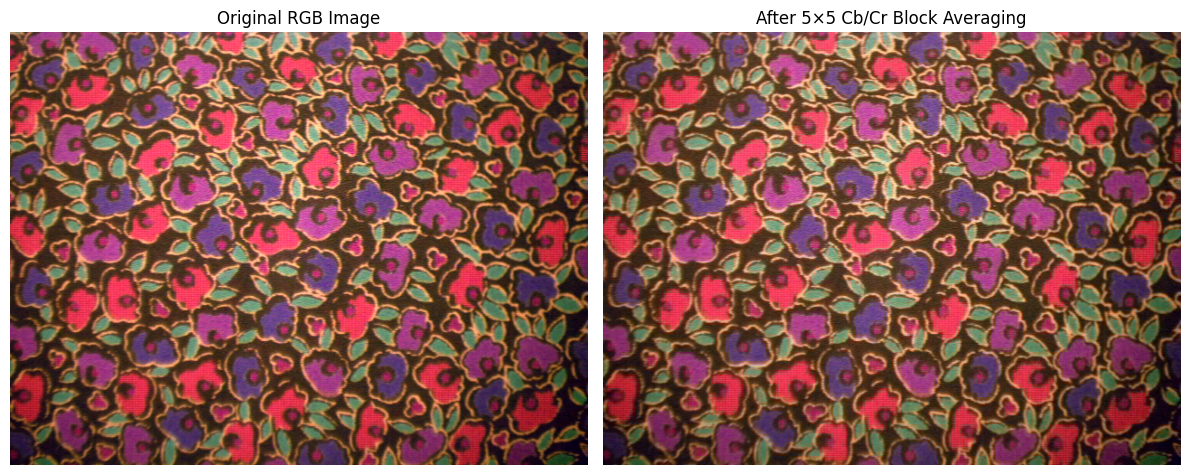

In [ ]:
Cb_subsampled = average_blocks(Cb, block_size=5)
Cr_subsampled = average_blocks(Cr, block_size=5)


ycbcr_subsampled = np.zeros_like(ycbcr_image)
ycbcr_subsampled[:, :, 0] = Y
ycbcr_subsampled[:, :, 1] = Cr_subsampled
ycbcr_subsampled[:, :, 2] = Cb_subsampled


rgb_subsampled = cv2.cvtColor(
    ycbcr_subsampled,
    cv2.COLOR_YCrCb2RGB
)
plt.figure(figsize=(12, 5))

# Original RGB image
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# RGB image after Cb and Cr 2x2 block averaging
plt.subplot(1, 2, 2)
plt.imshow(rgb_subsampled)
plt.title("After 5×5 Cb/Cr Block Averaging")
plt.axis("off")

plt.tight_layout()
plt.show()

# RGB

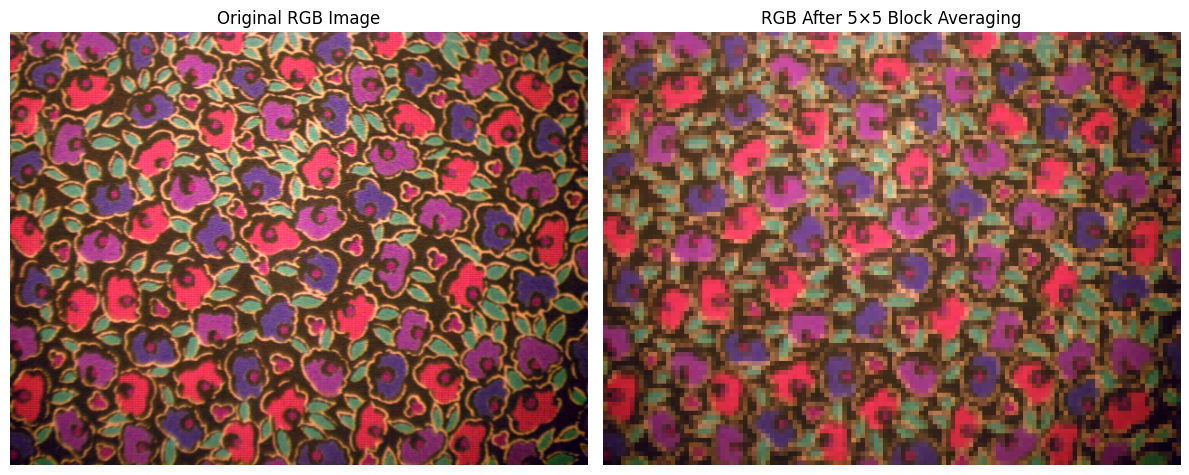

In [ ]:
rgb_averaged = average_rgb_blocks(rgb_image, block_size=5)

plt.figure(figsize=(12, 5))

# Original RGB image
plt.subplot(1, 2, 1)
plt.imshow(rgb_image)
plt.title("Original RGB Image")
plt.axis("off")

# RGB after 2x2 block averaging
plt.subplot(1, 2, 2)
plt.imshow(rgb_averaged)
plt.title("RGB After 5×5 Block Averaging")
plt.axis("off")

plt.tight_layout()
plt.show()

# Conclusion



*   5×5 Cb/Cr block averaging in YCbCr: The image retains most of its brightness and structural details because the Y channel is kept unchanged. Only the chrominance information is smoothed, so the visual quality remains relatively good.
*   5×5 RGB block averaging: The image becomes noticeably blurred and blocky. Since averaging is applied directly to R, G, and B, both color information and intensity/detail information are affected.


Comparison: This experiment shows why chroma subsampling is more effective in YCbCr than directly averaging RGB channels. Human vision is more sensitive to luminance/detail than to fine chrominance variations, so reducing chrominance resolution can save information while maintaining reasonable visual quality.
